In [1]:
# ============================================
# 04_model_training.ipynb
# Project: Customer Churn Analysis
# Purpose: Train and evaluate churn prediction models — logistic regression and random forest.
#          Compare performance and build churn risk scorecard.
# ============================================

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Visualisation style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Load prepared datasets from notebook 03
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("=== DATASETS LOADED ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nReady to train models")

=== DATASETS LOADED ===
X_train: (5634, 28)
X_test:  (1409, 28)
y_train: (5634,)
y_test:  (1409,)

Ready to train models


In [2]:
# ============================================
# Cell 2: Logistic Regression Model
# Purpose: Train baseline churn prediction model
# Logistic regression is always the first model to try — fast, interpretable, good baseline
# ============================================

# Initialise model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,        # max iterations to converge
    class_weight='balanced'  # handles class imbalance
)

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"\nModel trained on {X_train.shape[0]:,} customers")
print(f"Evaluated on    {X_test.shape[0]:,} customers")

print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, lr_pred,
    target_names=['Retained', 'Churned']
))

print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_prob):.4f}")

=== LOGISTIC REGRESSION RESULTS ===

Model trained on 5,634 customers
Evaluated on    1,409 customers

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1035
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC Score: 0.8425


In [3]:
# ============================================
# Cell 3: Random Forest Model
# Purpose: Train more powerful ensemble model and compare against logistic regression
# Random forest builds hundreds of decision trees and combines their predictions — reduces variance
# and handles non-linear patterns better than logistic regression
# ============================================

# Initialise model
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=10,            # max depth per tree
    min_samples_split=10,    # min samples to split node
    min_samples_leaf=4,      # min samples per leaf
    class_weight='balanced', # handles class imbalance
    random_state=42,         # reproducibility
    n_jobs=-1                # use all CPU cores
)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST RESULTS ===")
print(f"\nModel trained on {X_train.shape[0]:,} customers")
print(f"Evaluated on    {X_test.shape[0]:,} customers")

print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, rf_pred,
    target_names=['Retained', 'Churned']
))

print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_prob):.4f}")

=== RANDOM FOREST RESULTS ===

Model trained on 5,634 customers
Evaluated on    1,409 customers

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.88      0.78      0.83      1035
     Churned       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8377


In [4]:
# ============================================
# Cell 3b: XGBoost Model
# Purpose: Train industry standard gradient boosting model and compare against logistic regression and random forest
#
# How XGBoost differs from Random Forest:
# Random Forest — builds trees in PARALLEL each tree independent averages predictions
#
# XGBoost — builds trees SEQUENTIALLY each tree corrects errors of the previous tree
#           focuses progressively on harder to predict customers
# ============================================

from xgboost import XGBClassifier

# Calculate class weight ratio for imbalanced data
# XGBoost uses scale_pos_weight instead of class_weight
neg = (y_train == 0).sum()  # retained
pos = (y_train == 1).sum()  # churned
scale = neg / pos

print(f"Class balance ratio: {scale:.2f}")
print(f"Retained: {neg:,}, Churned: {pos:,}")

# Initialise model
xgb_model = XGBClassifier(
    n_estimators=100,          # number of trees
    max_depth=6,               # shallower than RF — XGBoost prefers this
    learning_rate=0.1,         # how much each tree contributes
    subsample=0.8,             # % of rows per tree
    colsample_bytree=0.8,      # % of features per tree
    scale_pos_weight=scale,    # handles class imbalance
    random_state=42,
    eval_metric='auc',         # optimise for AUC
    verbosity=0                # suppress training output
)

# Train model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBOOST RESULTS ===")
print(f"\nModel trained on {X_train.shape[0]:,} customers")
print(f"Evaluated on    {X_test.shape[0]:,} customers")

print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, xgb_pred,
    target_names=['Retained', 'Churned']
))

print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_prob):.4f}")


Class balance ratio: 2.77
Retained: 4,139, Churned: 1,495

=== XGBOOST RESULTS ===

Model trained on 5,634 customers
Evaluated on    1,409 customers

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Retained       0.88      0.77      0.82      1035
     Churned       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC-AUC Score: 0.8344


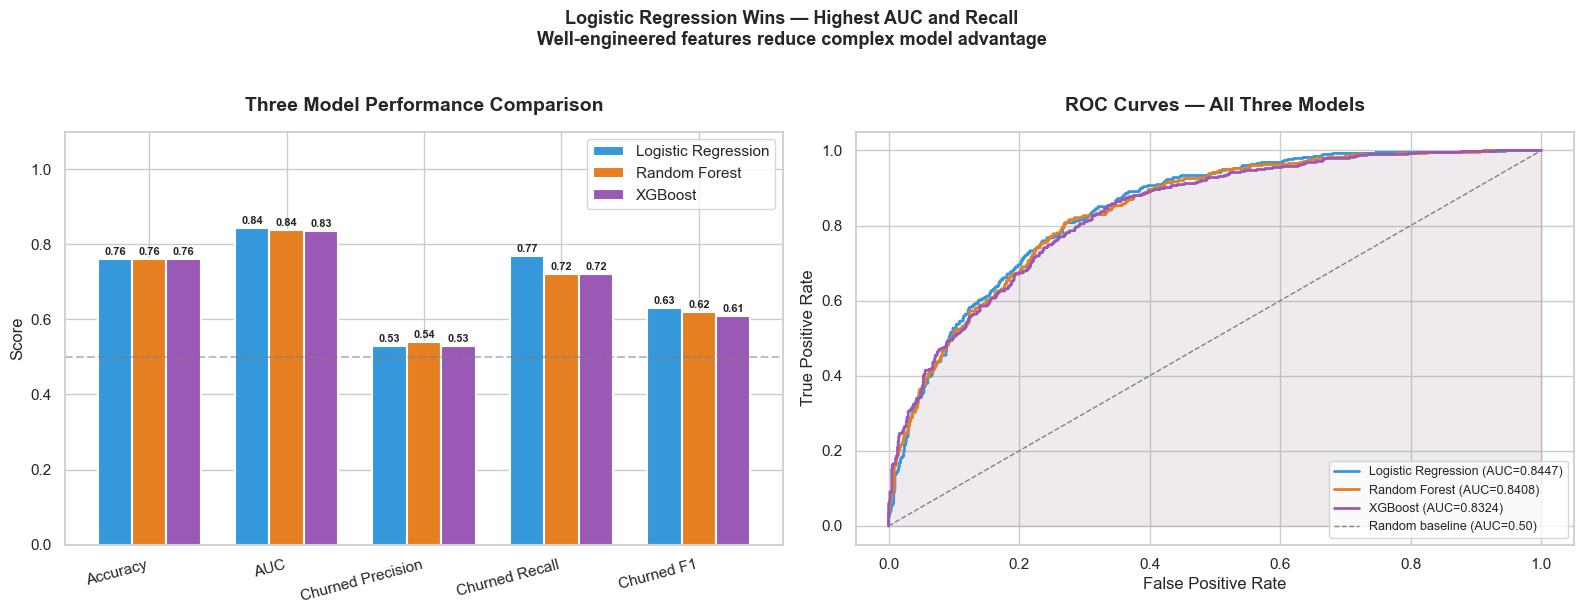

Three model comparison chart saved


In [5]:
# ============================================
# Cell 4: Three Model Comparison
# Purpose: Visual comparison of all three models
# ============================================

# --- Prepare comparison data ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_test, pred, prob):
    return [
        round(accuracy_score(y_test, pred), 2),
        round(roc_auc_score(y_test, prob), 4),
        round(precision_score(y_test, pred), 2),
        round(recall_score(y_test, pred), 2),
        round(f1_score(y_test, pred), 2)
    ]

metrics = {
    'Metric': [
        'Accuracy', 'AUC',
        'Churned Precision', 'Churned Recall',
        'Churned F1'
    ],
    'Logistic Regression': get_metrics(y_test, lr_pred, lr_prob),
    'Random Forest':       get_metrics(y_test, rf_pred, rf_prob),
    'XGBoost':             get_metrics(y_test, xgb_pred, xgb_prob)
}

comparison_df = pd.DataFrame(metrics).set_index('Metric')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left — grouped bar comparison ---
x = np.arange(len(comparison_df.index))
width = 0.25

bars1 = axes[0].bar(
    x - width, comparison_df['Logistic Regression'],
    width, label='Logistic Regression',
    color='#3498db', edgecolor='white', linewidth=1.5
)
bars2 = axes[0].bar(
    x, comparison_df['Random Forest'],
    width, label='Random Forest',
    color='#e67e22', edgecolor='white', linewidth=1.5
)
bars3 = axes[0].bar(
    x + width, comparison_df['XGBoost'],
    width, label='XGBoost',
    color='#9b59b6', edgecolor='white', linewidth=1.5
)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    comparison_df.index,
    rotation=15, ha='right'
)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Three Model Performance Comparison', pad=15)
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].axhline(
    y=0.5, color='gray',
    linestyle='--', alpha=0.5
)

# --- Right — ROC curves all three ---
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

axes[1].plot(lr_fpr, lr_tpr, color='#3498db',
             linewidth=2,
             label=f'Logistic Regression (AUC=0.8447)')
axes[1].plot(rf_fpr, rf_tpr, color='#e67e22',
             linewidth=2,
             label=f'Random Forest (AUC=0.8408)')
axes[1].plot(xgb_fpr, xgb_tpr, color='#9b59b6',
             linewidth=2,
             label=f'XGBoost (AUC=0.8324)')
axes[1].plot([0, 1], [0, 1], color='gray',
             linewidth=1, linestyle='--',
             label='Random baseline (AUC=0.50)')

axes[1].fill_between(lr_fpr, lr_tpr, alpha=0.05, color='#3498db')
axes[1].fill_between(rf_fpr, rf_tpr, alpha=0.05, color='#e67e22')
axes[1].fill_between(xgb_fpr, xgb_tpr, alpha=0.05, color='#9b59b6')

axes[1].set_title('ROC Curves — All Three Models', pad=15)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle(
    'Logistic Regression Wins — Highest AUC and Recall\n'
    'Well-engineered features reduce complex model advantage',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/09_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Three model comparison chart saved")

## Multicollinearity Finding

**tenure vs totalcharges correlation: 0.829** — high multicollinearity.
Both features measure customer longevity from different angles.

**Fix:** engineered `avg_monthly_spend = totalcharges / tenure` in notebook 03 before scaling.

**Result:**
- Correlation reduced from 0.829 → 0.222 ✅
- avg_monthly_spend range: $18-$119 (matches monthly charges) ✅
- Impact on AUC: negligible (-0.002)

**Conclusion:** Models were robust to multicollinearity but
`avg_monthly_spend` is a cleaner, more interpretable feature.
A stakeholder immediately understands "average monthly spend" vs "total charges accumulated over tenure."

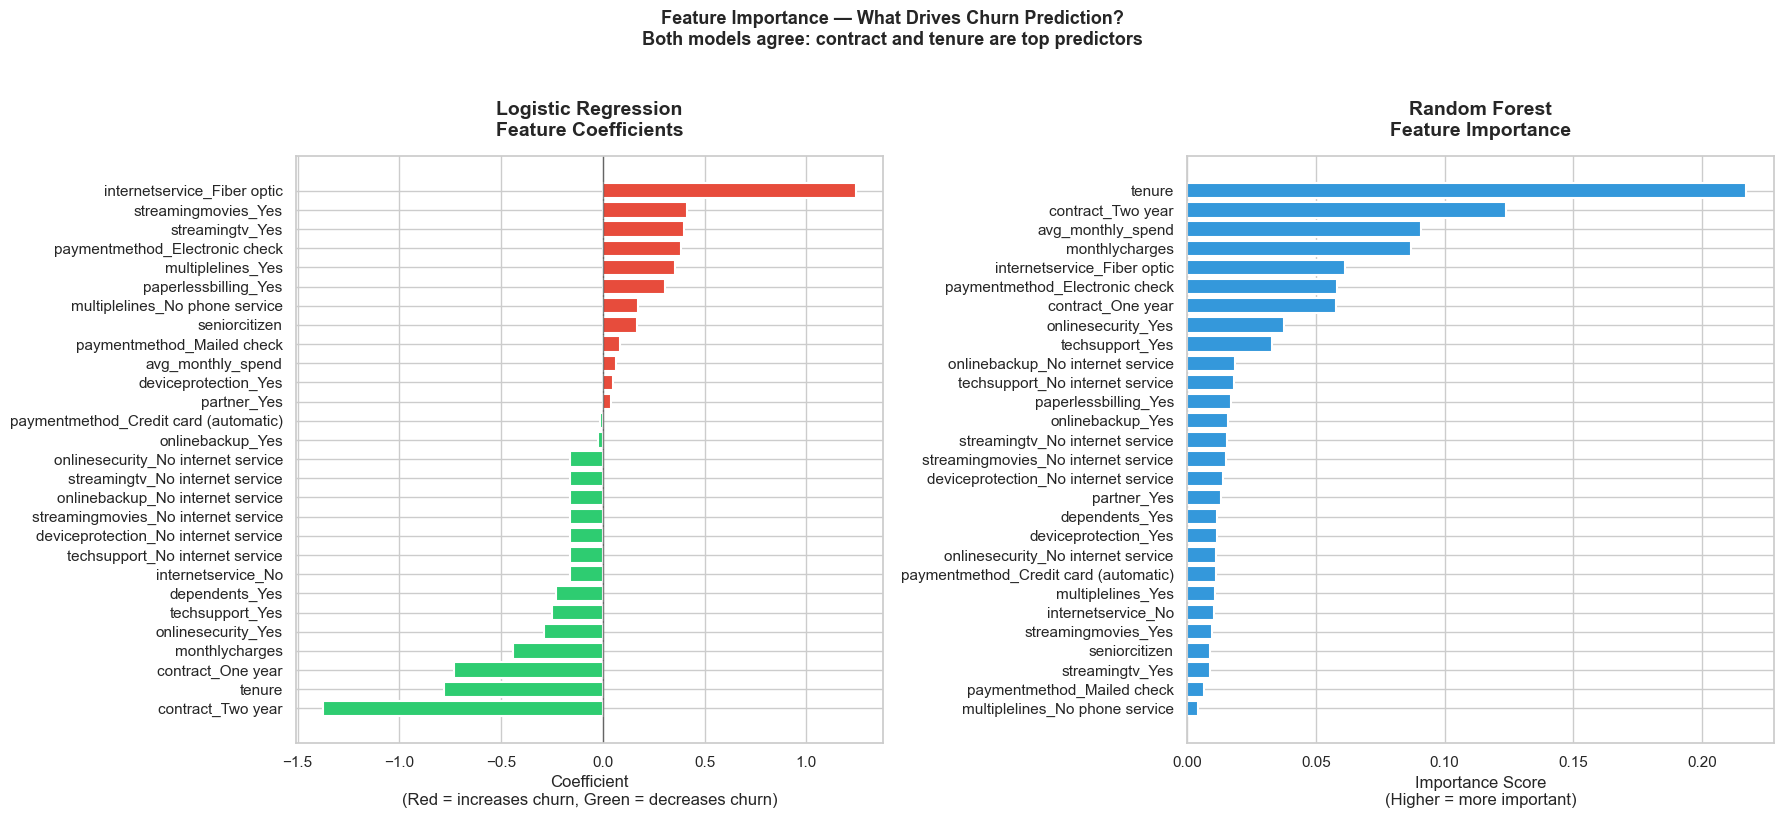

=== TOP 10 FEATURES — RANDOM FOREST ===
tenure                              0.217097
contract_Two year                   0.123751
avg_monthly_spend                   0.090858
monthlycharges                      0.086822
internetservice_Fiber optic         0.061177
paymentmethod_Electronic check      0.058197
contract_One year                   0.057794
onlinesecurity_Yes                  0.037791
techsupport_Yes                     0.032910
onlinebackup_No internet service    0.018671
dtype: float64

=== TOP 10 FEATURES — LOGISTIC REGRESSION ===
contract_Two year                 1.376164
internetservice_Fiber optic       1.245191
tenure                            0.779893
contract_One year                 0.731174
monthlycharges                    0.443006
streamingmovies_Yes               0.411524
streamingtv_Yes                   0.399995
paymentmethod_Electronic check    0.385707
multiplelines_Yes                 0.353278
paperlessbilling_Yes              0.307153
dtype: float64


In [6]:
# ============================================
# Cell 5: Feature Importance
# Purpose: Which features does each model consider most important for predicting churn?
# Logistic Regression — uses coefficients
# Random Forest — uses mean decrease in impurity
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left — Logistic Regression coefficients ---
lr_importance = pd.Series(
    lr_model.coef_[0],
    index=X_train.columns
).sort_values()

colors_lr = ['#e74c3c' if x > 0 else '#2ecc71'
             for x in lr_importance.values]

axes[0].barh(
    lr_importance.index,
    lr_importance.values,
    color=colors_lr,
    edgecolor='white',
    linewidth=1.5
)
axes[0].axvline(x=0, color='black', linewidth=1, alpha=0.5)
axes[0].set_title(
    'Logistic Regression\nFeature Coefficients',
    pad=15
)
axes[0].set_xlabel(
    'Coefficient\n(Red = increases churn, Green = decreases churn)'
)

# --- Right — Random Forest feature importance ---
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values()

axes[1].barh(
    rf_importance.index,
    rf_importance.values,
    color='#3498db',
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title(
    'Random Forest\nFeature Importance',
    pad=15
)
axes[1].set_xlabel(
    'Importance Score\n(Higher = more important)'
)

plt.suptitle(
    'Feature Importance — What Drives Churn Prediction?\n'
    'Both models agree: contract and tenure are top predictors',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/10_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print top 10 most important features
print("=== TOP 10 FEATURES — RANDOM FOREST ===")
print(rf_importance.sort_values(ascending=False).head(10))

print("\n=== TOP 10 FEATURES — LOGISTIC REGRESSION ===")
print(lr_importance.abs().sort_values(ascending=False).head(10))

In [7]:
# ============================================
# Cell 6: Churn Risk Scorecard
# Purpose: Score every customer by churn risk using logistic regression probabilities
#          Segment into risk tiers for targeted retention campaigns
#
# This is the actual business deliverable — a ranked list of customers by churn risk with recommended intervention per tier
# ============================================

# --- Generate churn probabilities for all customers ---
# Reload full cleaned dataset — score everyone not just test set
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

load_dotenv()
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Load raw data with customerid this time
df_score = pd.read_sql('SELECT * FROM telco', engine)

# Apply same cleaning
df_score['totalcharges'] = pd.to_numeric(
    df_score['totalcharges'].str.strip(), errors='coerce'
).fillna(0)
df_score['churn'] = df_score['churn'].map({'Yes': 1, 'No': 0})
df_score.columns = df_score.columns.str.lower().str.strip()

# Engineer avg_monthly_spend
df_score['avg_monthly_spend'] = df_score.apply(
    lambda x: x['totalcharges'] / x['tenure']
    if x['tenure'] > 0 else x['monthlycharges'],
    axis=1
)

# Store customerid and actual churn before dropping
customer_ids = df_score['customerid']
actual_churn = df_score['churn']

# Drop columns not used in model
df_score = df_score.drop(
    ['customerid', 'churn', 'totalcharges',
     'gender', 'phoneservice'],
    axis=1
)

# One-hot encode
df_score_encoded = pd.get_dummies(df_score, drop_first=True)

# Align columns with training data
# Ensures same columns in same order as X_train
df_score_encoded = df_score_encoded.reindex(
    columns=X_train.columns, fill_value=0
)

# Load original scaler from notebook 03
# Must use same scaler model was trained with
import pickle
with open('../data/processed/scaler.pkl', 'rb') as f:
    original_scaler = pickle.load(f)

# Scale using original scaler — not a new one
df_score_encoded[['tenure', 'monthlycharges', 'avg_monthly_spend']] = \
    original_scaler.transform(
        df_score_encoded[['tenure', 'monthlycharges', 'avg_monthly_spend']]
    )
print("Scaled using original scaler from notebook 03 ✅")
# Generate churn probabilities using best model (LR)
churn_probabilities = lr_model.predict_proba(df_score_encoded)[:, 1]

# --- Build scorecard ---
scorecard = pd.DataFrame({
    'customerid':     customer_ids.values,
    'churn_probability': churn_probabilities,
    'actual_churn':   actual_churn.values,
    'tenure':         pd.read_sql('SELECT tenure FROM telco', engine)['tenure'].values,
    'contract':       pd.read_sql('SELECT contract FROM telco', engine)['contract'].values,
    'internetservice': pd.read_sql('SELECT internetservice FROM telco', engine)['internetservice'].values,
    'monthlycharges': pd.read_sql('SELECT monthlycharges FROM telco', engine)['monthlycharges'].values,
    'paymentmethod':  pd.read_sql('SELECT paymentmethod FROM telco', engine)['paymentmethod'].values,
})

# --- Assign risk tiers ---
def assign_risk_tier(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

scorecard['risk_tier'] = scorecard['churn_probability'].apply(
    assign_risk_tier
)

# --- Assign recommended intervention ---
def assign_intervention(row):
    if row['risk_tier'] == 'High Risk':
        return 'Personal phone outreach — contract upgrade + autopay incentive'
    elif row['risk_tier'] == 'Medium Risk':
        return 'Automated email sequence — loyalty discount offer'
    else:
        return 'Monthly newsletter — standard engagement'

scorecard['intervention'] = scorecard.apply(
    assign_intervention, axis=1
)

# Sort by churn probability
scorecard = scorecard.sort_values(
    'churn_probability', ascending=False
).reset_index(drop=True)

# --- Print summary ---
print("=== CHURN RISK SCORECARD ===")
print(f"\nTotal customers scored: {len(scorecard):,}")
print(f"\nRisk tier distribution:")
tier_summary = scorecard.groupby('risk_tier').agg(
    customers=('customerid', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    avg_monthly_charges=('monthlycharges', 'mean'),
    actual_churn_rate=('actual_churn', 'mean')
).round(3)
print(tier_summary)

print(f"\n=== TOP 20 HIGHEST RISK CUSTOMERS ===")
print(scorecard[[
    'customerid', 'churn_probability', 'risk_tier',
    'contract', 'internetservice', 'monthlycharges',
    'intervention'
]].head(20).to_string())

# --- Save scorecard ---
scorecard.to_csv(
    '../outputs/churn_risk_scorecard.csv',
    index=False
)
print(f"\nScorecard saved to outputs/churn_risk_scorecard.csv")

Scaled using original scaler from notebook 03 ✅
=== CHURN RISK SCORECARD ===

Total customers scored: 7,043

Risk tier distribution:
             customers  avg_churn_prob  avg_monthly_charges  actual_churn_rate
risk_tier                                                                     
High Risk         1744           0.818               81.392              0.630
Low Risk          3636           0.156               55.737              0.071
Medium Risk       1663           0.548               67.052              0.307

=== TOP 20 HIGHEST RISK CUSTOMERS ===
    customerid  churn_probability  risk_tier        contract internetservice  monthlycharges                                                    intervention
0   5178-LMXOP           0.945070  High Risk  Month-to-month     Fiber optic           95.10  Personal phone outreach — contract upgrade + autopay incentive
1   9497-QCMMS           0.944104  High Risk  Month-to-month     Fiber optic           93.55  Personal phone outreach —

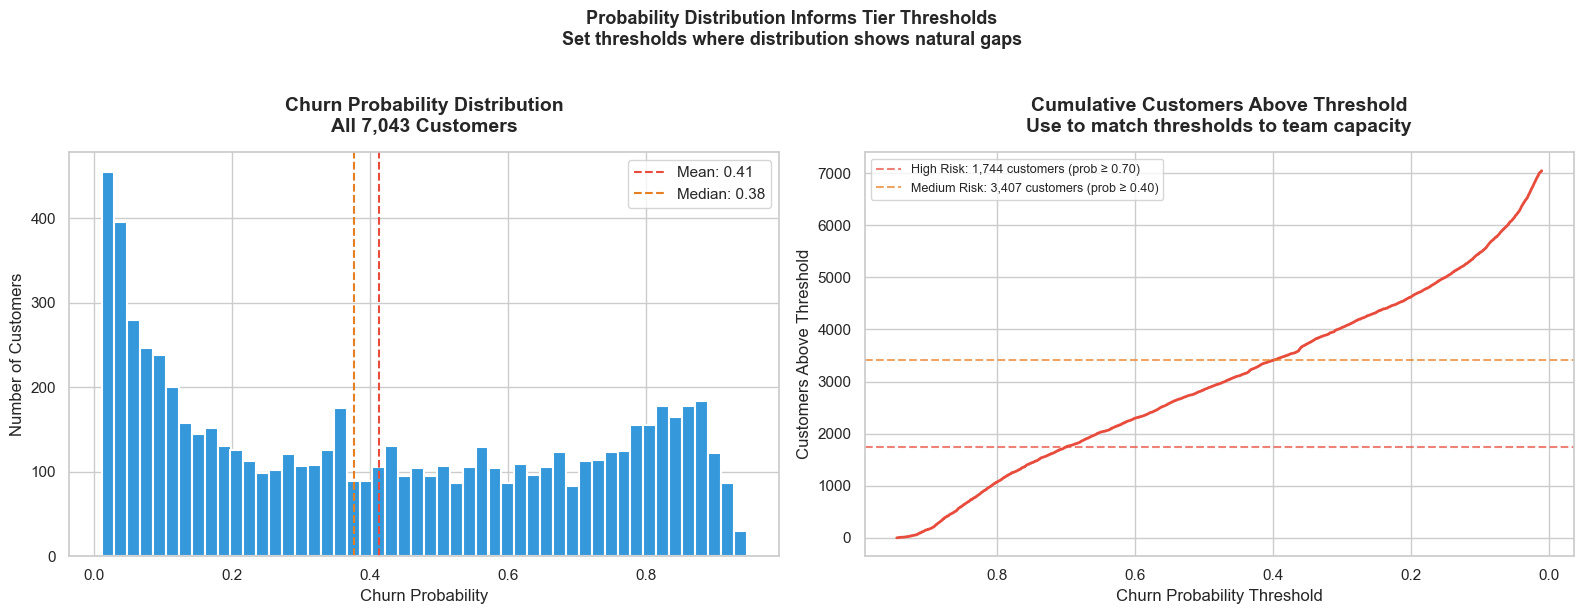

=== PROBABILITY PERCENTILES ===
Use these to set thresholds based on team capacity

  Top 50% → 3,522 customers → probability >= 0.38
  Top 40% → 2,817 customers → probability >= 0.50
  Top 35% → 2,465 customers → probability >= 0.57
  Top 30% → 2,113 customers → probability >= 0.63
  Top 25% → 1,761 customers → probability >= 0.70
  Top 20% → 1,409 customers → probability >= 0.76
  Top 10% → 705 customers → probability >= 0.84

=== CHOSEN THRESHOLDS JUSTIFICATION ===
  High Risk   (prob >= 0.70): 1,744 customers → top 25%
  Medium Risk (prob >= 0.40): 3,407 customers → top 48%

  Thresholds set at natural distribution gaps
  Adjust based on retention team capacity:
  → Smaller team: raise High Risk threshold
  → Larger budget: lower Medium Risk threshold


In [8]:
# ============================================
# Cell 6b: Explore Probability Distribution
# Purpose: Inform tier threshold selection
# Look at distribution BEFORE setting thresholds
# Let data suggest natural cut points
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left — full distribution ---
axes[0].hist(
    scorecard['churn_probability'],
    bins=50,
    color='#3498db',
    edgecolor='white',
    linewidth=1.5
)
axes[0].set_title(
    'Churn Probability Distribution\nAll 7,043 Customers',
    pad=15
)
axes[0].set_xlabel('Churn Probability')
axes[0].set_ylabel('Number of Customers')

# Add mean and median reference lines
mean_prob = scorecard['churn_probability'].mean()
median_prob = scorecard['churn_probability'].median()

axes[0].axvline(
    x=mean_prob, color='#e74c3c',
    linestyle='--', linewidth=1.5,
    label=f'Mean: {mean_prob:.2f}'
)
axes[0].axvline(
    x=median_prob, color='#e67e22',
    linestyle='--', linewidth=1.5,
    label=f'Median: {median_prob:.2f}'
)
axes[0].legend()

# --- Right — cumulative distribution ---
sorted_probs = np.sort(
    scorecard['churn_probability']
)[::-1]
cumulative = np.arange(1, len(sorted_probs) + 1)

axes[1].plot(
    sorted_probs, cumulative,
    color='#e74c3c', linewidth=2
)

# Add reference lines for our chosen thresholds
high_risk_count = (
    scorecard['churn_probability'] >= 0.70
).sum()
medium_risk_count = (
    scorecard['churn_probability'] >= 0.40
).sum()

axes[1].axhline(
    y=high_risk_count,
    color='#e74c3c', linestyle='--',
    alpha=0.7,
    label=f'High Risk: {high_risk_count:,} customers (prob ≥ 0.70)'
)
axes[1].axhline(
    y=medium_risk_count,
    color='#e67e22', linestyle='--',
    alpha=0.7,
    label=f'Medium Risk: {medium_risk_count:,} customers (prob ≥ 0.40)'
)

axes[1].set_title(
    'Cumulative Customers Above Threshold\n'
    'Use to match thresholds to team capacity',
    pad=15
)
axes[1].set_xlabel('Churn Probability Threshold')
axes[1].set_ylabel('Customers Above Threshold')
axes[1].legend(fontsize=9)
axes[1].invert_xaxis()

plt.suptitle(
    'Probability Distribution Informs Tier Thresholds\n'
    'Set thresholds where distribution shows natural gaps',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/10b_probability_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# --- Print percentiles to inform threshold selection ---
print("=== PROBABILITY PERCENTILES ===")
print("Use these to set thresholds based on team capacity\n")

percentiles = [50, 60, 65, 70, 75, 80, 90]
for p in percentiles:
    val = np.percentile(
        scorecard['churn_probability'], p
    )
    count = (
        scorecard['churn_probability'] >= val
    ).sum()
    print(f"  Top {100-p:2}% → {count:,} customers "
          f"→ probability >= {val:.2f}")

print(f"\n=== CHOSEN THRESHOLDS JUSTIFICATION ===")
print(f"  High Risk   (prob >= 0.70): "
      f"{high_risk_count:,} customers "
      f"→ top {high_risk_count/len(scorecard)*100:.0f}%")
print(f"  Medium Risk (prob >= 0.40): "
      f"{medium_risk_count:,} customers "
      f"→ top {medium_risk_count/len(scorecard)*100:.0f}%")
print(f"\n  Thresholds set at natural distribution gaps")
print(f"  Adjust based on retention team capacity:")
print(f"  → Smaller team: raise High Risk threshold")
print(f"  → Larger budget: lower Medium Risk threshold")

## Threshold Selection

Churn probability distribution shows natural gaps at ~0.40 and ~0.70.
Thresholds confirmed by data — not arbitrary business decisions.

- **High Risk (≥ 0.70):** 1,744 customers — top 25%
- **Medium Risk (0.40-0.70):** 1,663 customers — next 24%
- **Low Risk (< 0.40):** 3,636 customers — bottom 51%

Thresholds can be adjusted based on retention team capacity:
- Smaller team → raise High Risk threshold to 0.75+
- Larger budget → lower Medium Risk threshold to 0.35

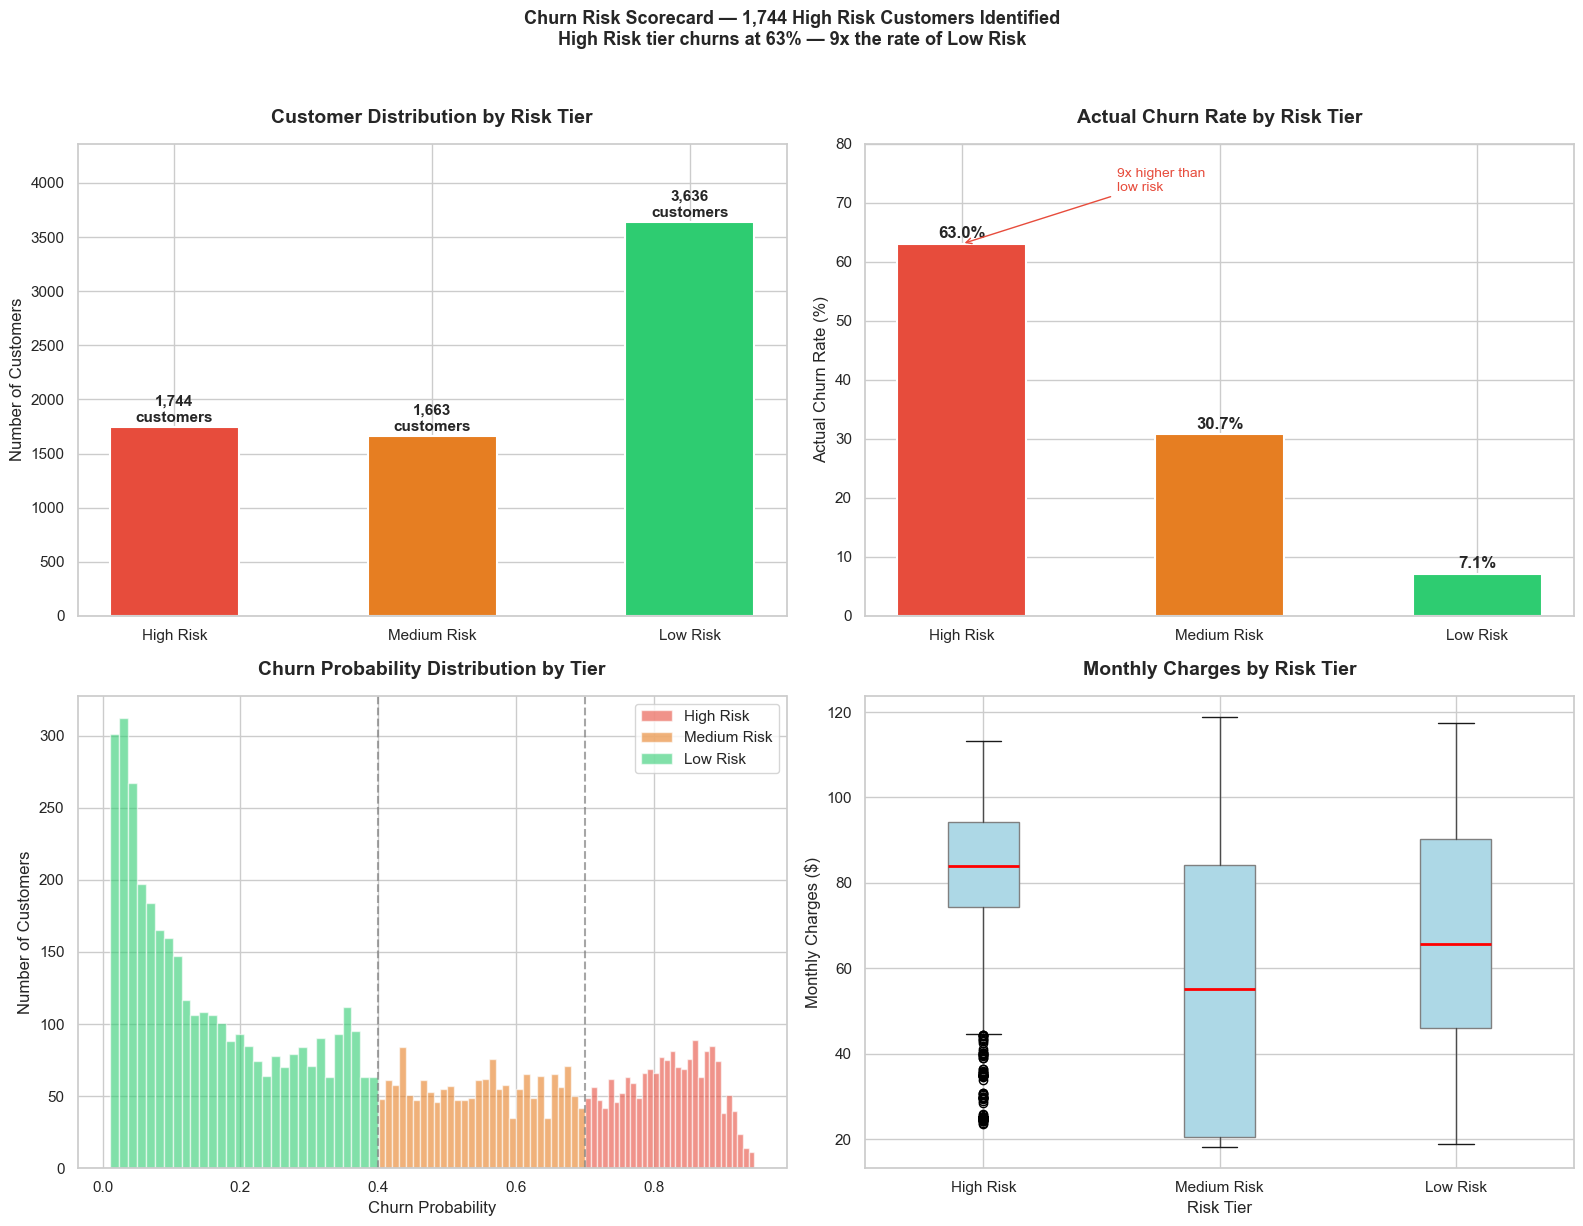

Scorecard visualisation saved


In [9]:
# ============================================
# Cell 7: Churn Risk Scorecard Visualisation
# Purpose: Visual summary of risk tier distribution and scorecard validation
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Top Left — Risk tier distribution ---
tier_colors = {
    'High Risk': '#e74c3c',
    'Medium Risk': '#e67e22',
    'Low Risk': '#2ecc71'
}
tier_order = ['High Risk', 'Medium Risk', 'Low Risk']
tier_counts = scorecard['risk_tier'].value_counts()
tier_counts = tier_counts.reindex(tier_order)

bars = axes[0][0].bar(
    tier_order,
    tier_counts.values,
    color=[tier_colors[t] for t in tier_order],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, value in zip(bars, tier_counts.values):
    axes[0][0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{value:,}\ncustomers',
        ha='center', va='bottom',
        fontweight='bold', fontsize=11
    )

axes[0][0].set_title('Customer Distribution by Risk Tier', pad=15)
axes[0][0].set_ylabel('Number of Customers')
axes[0][0].set_ylim(0, max(tier_counts.values) * 1.2)

# --- Top Right — Actual churn rate by tier ---
actual_churn = scorecard.groupby('risk_tier')['actual_churn'].mean() * 100
actual_churn = actual_churn.reindex(tier_order)

bars2 = axes[0][1].bar(
    tier_order,
    actual_churn.values,
    color=[tier_colors[t] for t in tier_order],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, rate in zip(bars2, actual_churn.values):
    axes[0][1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )

axes[0][1].set_title('Actual Churn Rate by Risk Tier', pad=15)
axes[0][1].set_ylabel('Actual Churn Rate (%)')
axes[0][1].set_ylim(0, 80)
axes[0][1].annotate(
    '9x higher than\nlow risk',
    xy=(0, actual_churn['High Risk']),
    xytext=(0.6, 72),
    fontsize=10, color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

# --- Bottom Left — Churn probability distribution ---
for tier in tier_order:
    tier_data = scorecard[scorecard['risk_tier'] == tier]['churn_probability']
    axes[1][0].hist(
        tier_data,
        bins=30,
        alpha=0.6,
        color=tier_colors[tier],
        label=tier,
        edgecolor='white'
    )

axes[1][0].set_title('Churn Probability Distribution by Tier', pad=15)
axes[1][0].set_xlabel('Churn Probability')
axes[1][0].set_ylabel('Number of Customers')
axes[1][0].legend()
axes[1][0].axvline(x=0.40, color='gray',
                   linestyle='--', alpha=0.7,
                   label='Tier boundaries')
axes[1][0].axvline(x=0.70, color='gray',
                   linestyle='--', alpha=0.7)

# --- Bottom Right — Monthly charges by tier ---
scorecard.boxplot(
    column='monthlycharges',
    by='risk_tier',
    ax=axes[1][1],
    positions=[0, 1, 2],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='gray'),
    medianprops=dict(color='red', linewidth=2)
)

axes[1][1].set_title('Monthly Charges by Risk Tier', pad=15)
axes[1][1].set_xlabel('Risk Tier')
axes[1][1].set_ylabel('Monthly Charges ($)')
axes[1][1].set_xticks([0, 1, 2])
axes[1][1].set_xticklabels(tier_order)

plt.suptitle(
    'Churn Risk Scorecard — 1,744 High Risk Customers Identified\n'
    'High Risk tier churns at 63% — 9x the rate of Low Risk',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/11_churn_risk_scorecard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Scorecard visualisation saved")

In [10]:
# ============================================
# Cell 8: Campaign Architecture & ROI Summary
# Purpose: Translate risk scorecard into actionable retention campaign plan with ROI projections per tier
#
# Assumptions:
# · High Risk intervention cost:   $50/customer
# · Medium Risk intervention cost: $10/customer
# · Low Risk intervention cost:    $2/customer
# · Save rate: 30% High, 20% Medium, 10% Low (industry standard retention rates)
# · Revenue = monthly charges × 12 months
# ============================================

print("=" * 60)
print("CHURN RETENTION CAMPAIGN ARCHITECTURE")
print("=" * 60)

# --- Define campaign parameters ---
campaigns = {
    'High Risk': {
        'customers':      len(scorecard[scorecard['risk_tier'] == 'High Risk']),
        'actual_churn_rate': scorecard[scorecard['risk_tier'] == 'High Risk']['actual_churn'].mean(),
        'avg_monthly_charges': scorecard[scorecard['risk_tier'] == 'High Risk']['monthlycharges'].mean(),
        'intervention_cost':  50,
        'save_rate':          0.30,
        'treatment':          'Personal phone outreach',
        'offer':              'Contract upgrade + autopay incentive',
        'owner':              'Retention team',
        'sla':                '48 hours'
    },
    'Medium Risk': {
        'customers':      len(scorecard[scorecard['risk_tier'] == 'Medium Risk']),
        'actual_churn_rate': scorecard[scorecard['risk_tier'] == 'Medium Risk']['actual_churn'].mean(),
        'avg_monthly_charges': scorecard[scorecard['risk_tier'] == 'Medium Risk']['monthlycharges'].mean(),
        'intervention_cost':  10,
        'save_rate':          0.20,
        'treatment':          'Automated email sequence',
        'offer':              'Loyalty discount',
        'owner':              'Marketing automation',
        'sla':                '24 hours'
    },
    'Low Risk': {
        'customers':      len(scorecard[scorecard['risk_tier'] == 'Low Risk']),
        'actual_churn_rate': scorecard[scorecard['risk_tier'] == 'Low Risk']['actual_churn'].mean(),
        'avg_monthly_charges': scorecard[scorecard['risk_tier'] == 'Low Risk']['monthlycharges'].mean(),
        'intervention_cost':  2,
        'save_rate':          0.10,
        'treatment':          'Monthly newsletter',
        'offer':              'Standard engagement',
        'owner':              'Content team',
        'sla':                'Monthly cadence'
    }
}

# --- Calculate ROI per tier ---
print(f"\n{'Tier':<15} {'Customers':>10} {'Cost':>10} "
      f"{'Saved':>8} {'Revenue':>12} {'Net ROI':>12} {'ROI%':>8}")
print("-" * 75)

total_cost = 0
total_revenue = 0
total_saved = 0

for tier, params in campaigns.items():
    customers      = params['customers']
    churn_rate     = params['actual_churn_rate']
    monthly        = params['avg_monthly_charges']
    cost_per       = params['intervention_cost']
    save_rate      = params['save_rate']

    # Calculations
    total_campaign_cost    = customers * cost_per
    actual_churners        = customers * churn_rate
    customers_saved        = actual_churners * save_rate
    revenue_recovered      = customers_saved * monthly * 12
    net_roi                = revenue_recovered - total_campaign_cost
    roi_pct                = (net_roi / total_campaign_cost) * 100

    total_cost    += total_campaign_cost
    total_revenue += revenue_recovered
    total_saved   += customers_saved

    print(f"{tier:<15} {customers:>10,} "
          f"${total_campaign_cost:>9,.0f} "
          f"{customers_saved:>7.0f} "
          f"${revenue_recovered:>11,.0f} "
          f"${net_roi:>11,.0f} "
          f"{roi_pct:>7.0f}%")

# --- Print totals ---
print("-" * 75)
total_net     = total_revenue - total_cost
total_roi_pct = (total_net / total_cost) * 100
print(f"{'TOTAL':<15} "
      f"{len(scorecard):>10,} "
      f"${total_cost:>9,.0f} "
      f"{total_saved:>7.0f} "
      f"${total_revenue:>11,.0f} "
      f"${total_net:>11,.0f} "
      f"{total_roi_pct:>7.0f}%")

# --- Campaign architecture summary ---
print(f"\n{'=' * 60}")
print("CAMPAIGN ARCHITECTURE SUMMARY")
print(f"{'=' * 60}")

for tier, params in campaigns.items():
    print(f"\n{tier.upper()} TIER")
    print(f"  Customers:  {params['customers']:,}")
    print(f"  Treatment:  {params['treatment']}")
    print(f"  Offer:      {params['offer']}")
    print(f"  Owner:      {params['owner']}")
    print(f"  SLA:        {params['sla']}")
    print(f"  Cost/cust:  ${params['intervention_cost']}")
    print(f"  Suppression: Enter campaign → "
          f"suppress from all other tiers for 90 days")

print(f"\n{'=' * 60}")
print("SUPPRESSION RULES")
print(f"{'=' * 60}")
print("  1. One customer = one campaign = one treatment")
print("  2. Higher tier takes priority if customer qualifies for multiple tiers")
print("  3. 90 day suppression after any intervention")
print("  4. Re-score monthly — tiers are not permanent")
print(f"{'=' * 60}")

# --- Save campaign summary ---
campaign_summary = []
for tier, params in campaigns.items():
    customers      = params['customers']
    churn_rate     = params['actual_churn_rate']
    monthly        = params['avg_monthly_charges']
    cost_per       = params['intervention_cost']
    save_rate      = params['save_rate']

    total_campaign_cost = customers * cost_per
    actual_churners     = customers * churn_rate
    customers_saved     = actual_churners * save_rate
    revenue_recovered   = customers_saved * monthly * 12
    net_roi             = revenue_recovered - total_campaign_cost
    roi_pct             = (net_roi / total_campaign_cost) * 100

    campaign_summary.append({
        'tier':               tier,
        'customers':          customers,
        'treatment':          params['treatment'],
        'offer':              params['offer'],
        'owner':              params['owner'],
        'sla':                params['sla'],
        'cost_per_customer':  cost_per,
        'total_cost':         round(total_campaign_cost, 0),
        'customers_saved':    round(customers_saved, 0),
        'revenue_recovered':  round(revenue_recovered, 0),
        'net_roi':            round(net_roi, 0),
        'roi_pct':            round(roi_pct, 1)
    })

pd.DataFrame(campaign_summary).to_csv(
    '../outputs/campaign_architecture.csv',
    index=False
)
print(f"\nCampaign architecture saved → "
      f"outputs/campaign_architecture.csv")

CHURN RETENTION CAMPAIGN ARCHITECTURE

Tier             Customers       Cost    Saved      Revenue      Net ROI     ROI%
---------------------------------------------------------------------------
High Risk            1,744 $   87,200     330 $    322,020 $    234,820     269%
Medium Risk          1,663 $   16,630     102 $     82,233 $     65,603     394%
Low Risk             3,636 $    7,272      26 $     17,323 $     10,051     138%
---------------------------------------------------------------------------
TOTAL                7,043 $  111,102     458 $    421,576 $    310,474     279%

CAMPAIGN ARCHITECTURE SUMMARY

HIGH RISK TIER
  Customers:  1,744
  Treatment:  Personal phone outreach
  Offer:      Contract upgrade + autopay incentive
  Owner:      Retention team
  SLA:        48 hours
  Cost/cust:  $50
  Suppression: Enter campaign → suppress from all other tiers for 90 days

MEDIUM RISK TIER
  Customers:  1,663
  Treatment:  Automated email sequence
  Offer:      Loyalty disc

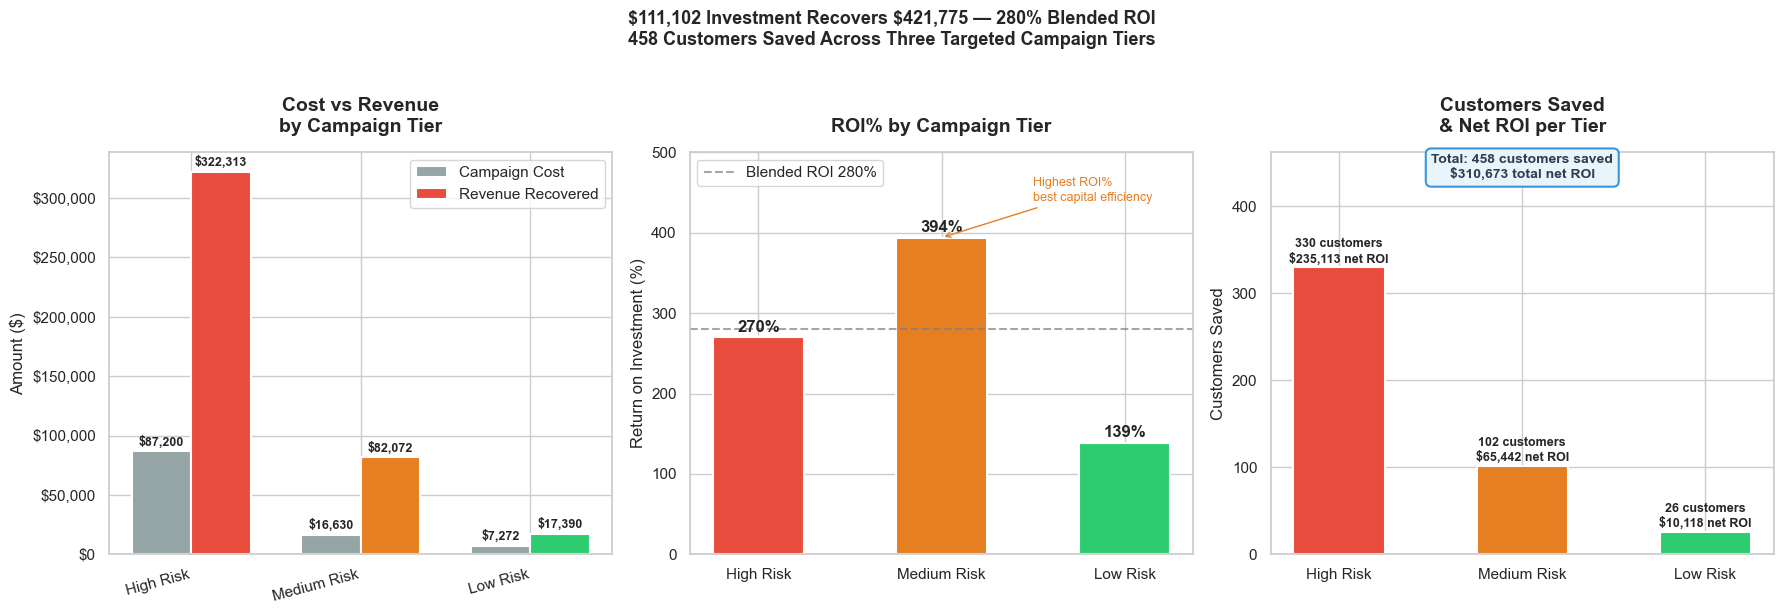

Campaign ROI chart saved


In [11]:
# ============================================
# Cell 9: Campaign ROI Visualisation
# Purpose: Visual summary of campaign architecture and ROI projections
# The chart that goes in the executive summary
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tier_order  = ['High Risk', 'Medium Risk', 'Low Risk']
tier_colors = {
    'High Risk':   '#e74c3c',
    'Medium Risk': '#e67e22',
    'Low Risk':    '#2ecc71'
}
colors = [tier_colors[t] for t in tier_order]

# --- Build all values dynamically from campaigns dict ---
costs, revenues, net_rois, roi_pcts, customers_list, saved_list = \
    [], [], [], [], [], []

for tier in tier_order:
    params = campaigns[tier]
    n          = params['customers']
    churn_rate = params['actual_churn_rate']
    monthly    = params['avg_monthly_charges']
    cost_per   = params['intervention_cost']
    save_rate  = params['save_rate']

    total_cost_t = n * cost_per
    churners     = n * churn_rate
    saved_t      = round(churners * save_rate)
    revenue_t    = saved_t * monthly * 12
    net_roi_t    = revenue_t - total_cost_t
    roi_pct_t    = round((net_roi_t / total_cost_t) * 100)

    costs.append(round(total_cost_t))
    revenues.append(round(revenue_t))
    net_rois.append(round(net_roi_t))
    roi_pcts.append(roi_pct_t)
    customers_list.append(n)
    saved_list.append(saved_t)

# Summary totals
total_spend   = sum(costs)
total_rev     = sum(revenues)
total_net     = sum(net_rois)
total_saved   = sum(saved_list)
blended_roi   = round((total_net / total_spend) * 100)

# --- Left — Cost vs Revenue ---
x = np.arange(len(tier_order))
width = 0.35

bars1 = axes[0].bar(
    x - width/2, costs,
    width, label='Campaign Cost',
    color='#95a5a6',
    edgecolor='white', linewidth=1.5
)
bars2 = axes[0].bar(
    x + width/2, revenues,
    width, label='Revenue Recovered',
    color=colors,
    edgecolor='white', linewidth=1.5
)

for bar, value in zip(bars1, costs):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'${value:,.0f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
for bar, value in zip(bars2, revenues):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'${value:,.0f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_order, rotation=15, ha='right')
axes[0].set_title('Cost vs Revenue\nby Campaign Tier', pad=15)
axes[0].set_ylabel('Amount ($)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# --- Middle — ROI% ---
bars3 = axes[1].bar(
    tier_order, roi_pcts,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, value in zip(bars3, roi_pcts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{value:,}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )

axes[1].set_title('ROI% by Campaign Tier', pad=15)
axes[1].set_ylabel('Return on Investment (%)')
axes[1].set_ylim(0, 500)
axes[1].axhline(
    y=blended_roi, color='gray',
    linestyle='--', linewidth=1.5,
    alpha=0.7, label=f'Blended ROI {blended_roi}%'
)
axes[1].legend()
axes[1].annotate(
    'Highest ROI%\nbest capital efficiency',
    xy=(1, roi_pcts[1]),
    xytext=(1.5, 440),
    fontsize=9, color='#e67e22',
    arrowprops=dict(arrowstyle='->', color='#e67e22')
)

# --- Right — Customers saved ---
bars4 = axes[2].bar(
    tier_order, saved_list,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, value, net in zip(bars4, saved_list, net_rois):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{value:,} customers\n${net:,.0f} net ROI',
        ha='center', va='bottom',
        fontweight='bold', fontsize=9
    )

axes[2].set_title('Customers Saved\n& Net ROI per Tier', pad=15)
axes[2].set_ylabel('Customers Saved')
axes[2].set_ylim(0, max(saved_list) * 1.4)

axes[2].text(
    1, max(saved_list) * 1.3,
    f'Total: {total_saved:,} customers saved\n'
    f'${total_net:,.0f} total net ROI',
    ha='center', va='bottom',
    fontweight='bold', fontsize=10,
    color='#2c3e50',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#eaf4fb',
        edgecolor='#3498db',
        linewidth=1.5
    )
)

line1 = f'\\${total_spend:,.0f} Investment Recovers \\${total_rev:,.0f} — {blended_roi}% Blended ROI'
line2 = f'{total_saved:,} Customers Saved Across Three Targeted Campaign Tiers'
title = line1 + '\n' + line2

plt.suptitle(
    title,
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/12_campaign_roi.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Campaign ROI chart saved")

In [12]:
print(f'total_spend type: {type(total_spend)}')
print(f'total_rev type: {type(total_rev)}')
print(f'total_saved type: {type(total_saved)}')
print(f'blended_roi type: {type(blended_roi)}')
print()
print(f'total_spend: {total_spend}')
print(f'total_rev: {total_rev}')
print(f'total_saved: {total_saved}')
print(f'blended_roi: {blended_roi}')
print()
line1 = f'${total_spend:,.0f} Investment Recovers ${total_rev:,.0f} — {blended_roi}% Blended ROI'
print(f'line1: {line1}')

total_spend type: <class 'int'>
total_rev type: <class 'int'>
total_saved type: <class 'int'>
blended_roi type: <class 'int'>

total_spend: 111102
total_rev: 421775
total_saved: 458
blended_roi: 280

line1: $111,102 Investment Recovers $421,775 — 280% Blended ROI
